# NLP with Disaster Tweets – Deep Learning Mini Project

This Project will look at the Kaggle disaster tweets competition. In the provided dataset are tweets (strings) wich are classfied if there are about a real deasaster or not. According to that they are classified with 0,1 respectively. There are arround 8k tweets inside the dataset.

## 1. Setup

In [ ]:
#Setup
!pip install -q kaggle
!pip install -q tensorflow
!pip install -q seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Download Disaster Tweets Data from Kaggle



In [ ]:
!pip install -q kaggle

import os

os.environ["KAGGLE_USERNAME"] = ""
os.environ["KAGGLE_KEY"] = ""


In [ ]:
!mkdir -p data

!kaggle competitions download -c nlp-getting-started -p data

!ls -lh data

!unzip -q data/nlp-getting-started.zip -d data
!ls -lh data

  0% 0.00/593k [00:00<?, ?B/s]
100% 593k/593k [00:00<00:00, 1.08GB/s]
total 596K
-rw-r--r-- 1 root root 594K Dec 16  2019 nlp-getting-started.zip
total 2.0M
-rw-r--r-- 1 root root 594K Dec 16  2019 nlp-getting-started.zip
-rw-r--r-- 1 root root  23K Dec 16  2019 sample_submission.csv
-rw-r--r-- 1 root root 411K Dec 16  2019 test.csv
-rw-r--r-- 1 root root 965K Dec 16  2019 train.csv


In [ ]:
DATEN_VERZEICHNIS = "data"
pfad_train = os.path.join(DATEN_VERZEICHNIS, "train.csv")
pfad_test = os.path.join(DATEN_VERZEICHNIS, "test.csv")

train_daten = pd.read_csv(pfad_train)
test_daten = pd.read_csv(pfad_test)

train_daten.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Exploratory Data Analysis (EDA)

- Check dataset size & structure  
- Inspect missing values  
- Look at target distribution  
- Look at tweet length distribution to pick a reasonable sequence length
- Look at the existance of @ / urls uppercase and so on for text cleaning purposes

In [ ]:
print("Train shape:", train_daten.shape)
print("Test shape:", test_daten.shape)
print("\nColumns:", train_daten.columns.tolist())
train_daten.info()

Train shape: (7613, 5)
Test shape: (3263, 4)

Columns: ['id', 'keyword', 'location', 'text', 'target']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
train_daten.isna().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


target
0    4342
1    3271
Name: count, dtype: int64


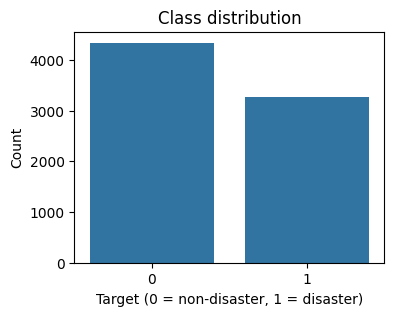

In [ ]:
target_counts = train_daten["target"].value_counts()
print(target_counts)

plt.figure(figsize=(4,3))
sns.barplot(x=target_counts.index, ziele=target_counts.values)
plt.xlabel("Target (0 = non-disaster, 1 = disaster)")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

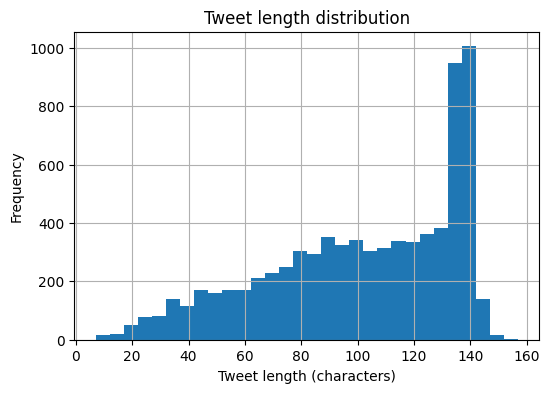

Max length: 157
Mean length: 101.03743596479706


In [ ]:
train_daten["text_length"] = train_daten["text"].astype(str).apply(len)

plt.figure(figsize=(6,4))
train_daten["text_length"].hist(bins=30)
plt.xlabel("Tweet length (characters)")
plt.ylabel("Frequency")
plt.title("Tweet length distribution")
plt.show()

print("Max length:", train_daten["text_length"].max())
print("Mean length:", train_daten["text_length"].mean())

In [ ]:
import re
import string

URL_MUSTER = r"http\S+"

has_url      = train_daten["text"].str.contains(URL_MUSTER, regex=True)
has_mention  = train_daten["text"].str.contains(r"@\w+", regex=True)
has_hashtag  = train_daten["text"].str.contains(r"#\w+", regex=True)
has_digit    = train_daten["text"].str.contains(r"\d", regex=True)
has_upper    = train_daten["text"].str.contains(r"[A-Z]", regex=True)
has_punct    = train_daten["text"].str.contains("[" + re.escape(string.punctuation) + "]", regex=True)

summary = pd.DataFrame({
    "contains_url (http...)":      [has_url.sum()],
    "contains_mention (@)":        [has_mention.sum()],
    "contains_hashtag (#)":        [has_hashtag.sum()],
    "contains_digit (0-9)":        [has_digit.sum()],
    "contains_uppercase (A-Z)":    [has_upper.sum()],
    "contains_punctuation (.,!?":  [has_punct.sum()],
}, index=["count_in_train"])

display(summary)

mask_dirty = has_url | has_mention | has_hashtag | has_digit | has_upper | has_punct
train_daten.loc[mask_dirty, ["text"]].head(10)


,contains_url (http...),contains_mention (@),contains_hashtag (#),contains_digit (0-9),contains_uppercase (A-Z),"contains_punctuation (.,!?"
count_in_train,3971,2009,1743,4525,7333,7271


,text
0,Our Deeds are the Reason of this #earthquake M...
1,Forest fire near La Ronge Sask. Canada
2,All residents asked to 'shelter in place' are ...
3,"13,000 people receive #wildfires evacuation or..."
4,Just got sent this photo from Ruby #Alaska as ...
5,#RockyFire Update => California Hwy. 20 closed...
6,#flood #disaster Heavy rain causes flash flood...
7,I'm on top of the hill and I can see a fire in...
8,There's an emergency evacuation happening now ...
9,I'm afraid that the tornado is coming to our a...


In [ ]:
train_daten[["text", "target"]].sample(5, random_state=42)

,text,target
2644,So you have a new weapon that can cause un-ima...,1
2227,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,Aftershock back to school kick off was great. ...,0
6845,in response to trauma Children of Addicts deve...,0


### Plan Based on EDA

Tweets are diffent in length I will assume that this will make no differance because of the tweet length limit we dont really have outliars regarding length. But before tokenising the text, I will clean the text (clean numbers punctuations uppercase and so on)



## 4. Text Cleaning

We apply simple, standard cleaning:

- Lowercase text  
- Remove URLs
- Remove Twitter mentions   
- Remove hashtag symbol but keep the word  
- Remove punctuation and digits  
- Collapse multiple spaces

In [ ]:
URL_MUSTER = r"http\S+"
ERWAEHNUNGS_MUSTER = r"@\w+"

def clean_text(text):
    text = str(text).lower()
    text = re.sub(URL_MUSTER, " ", text)
    text = re.sub(ERWAEHNUNGS_MUSTER, " ", text)
    text = text.replace("#", " ")
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_daten["clean_text"] = train_daten["text"].apply(clean_text)
test_daten["clean_text"] = test_daten["text"].apply(clean_text)

train_daten[["text", "clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


## 5. Tokenisation

Next I split the dataset into a training and validation dataset, then use a tokeniser to transform the text into ML able numbers

In [ ]:
texte = train_daten["clean_text"].values
ziele = train_daten["target"].values

texte_train, texte_val, y_train, y_val = train_test_split(
    texte, ziele, test_size=0.2, random_state=42, stratify=ziele
)

print("Train size:", len(texte_train))
print("Val size:", len(texte_val))

Train size: 6090
Val size: 1523


In [ ]:
# Tokenization

MAX_VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 40
OOV_TOKEN = "<OOV>"

tokenisierer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenisierer.fit_on_texts(train_daten["clean_text"].values)

train_sequences = tokenisierer.texts_to_sequences(texte_train)
val_sequences = tokenisierer.texts_to_sequences(texte_val)

X_train_gepadded = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH,
                            padding="post", truncating="post")
X_val_gepadded = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LENGTH,
                          padding="post", truncating="post")

print("Padded train shape:", X_train_gepadded.shape)
print("Padded val shape:", X_val_gepadded.shape)

Padded train shape: (6090, 40)
Padded val shape: (1523, 40)


## 6. BiLSTM Model

The BiLLSTM Model will have the follong layers.
- Embedding(vocab_size, embedding_dim)  
- Bidirectional LSTM(lstm_units)  
- Dropout  
- Dense(32, relu)  
- Dropout  
- Dense(1, sigmoid)

In [ ]:
# Build modell

def baue_bilstm_modell(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=64,
    max_length=MAX_SEQUENCE_LENGTH,
    lstm_units=64,
    dropout_rate=0.5
):
    modell = Sequential()
    modell.add(Embedding(vocab_size, embedding_dim, input_length=max_length))
    modell.add(Bidirectional(LSTM(lstm_units)))
    modell.add(Dropout(dropout_rate))
    modell.add(Dense(32, activation="relu"))
    modell.add(Dropout(dropout_rate))
    modell.add(Dense(1, activation="sigmoid"))

    modell.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return modell

modell = baue_bilstm_modell()
modell.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train modell

EPOCHS = 6
BATCH_SIZE = 64

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

verlauf = modell.fit(
    X_train_gepadded,
    y_train,
    validation_data=(X_val_gepadded, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5852 - loss: 0.6708 - val_accuracy: 0.7919 - val_loss: 0.4642
Epoch 2/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8471 - loss: 0.3739 - val_accuracy: 0.7905 - val_loss: 0.4602
Epoch 3/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9219 - loss: 0.2346 - val_accuracy: 0.7846 - val_loss: 0.5271
Epoch 4/6
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9510 - loss: 0.1494 - val_accuracy: 0.7800 - val_loss: 0.7253
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


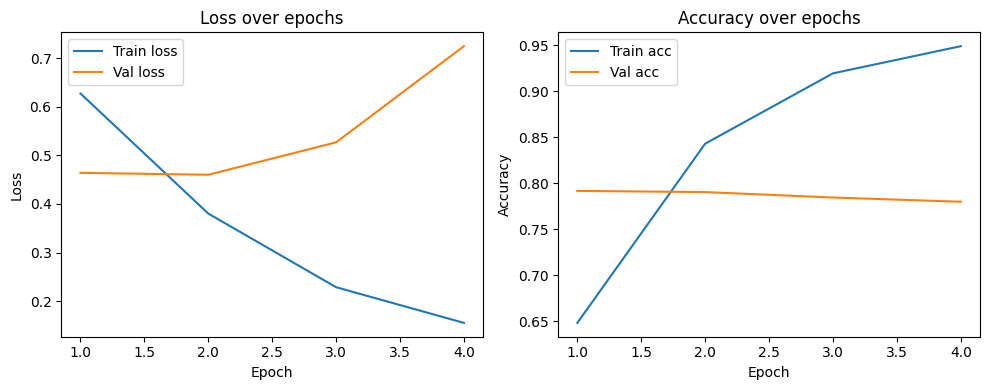

In [ ]:
def plot_verlauf(verlauf):
    hist = verlauf.verlauf
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist["loss"], label="Train loss")
    plt.plot(epochs, hist["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, hist["accuracy"], label="Train acc")
    plt.plot(epochs, hist["val_accuracy"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_verlauf(verlauf)

In [ ]:
y_val_pred_prob = modell.predict(X_val_gepadded)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

print("BiLSTM Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_val, y_val_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
BiLSTM Validation Accuracy: 0.7905449770190414

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       869
           1       0.76      0.76      0.76       654

    accuracy                           0.79      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.79      0.79      0.79      1523



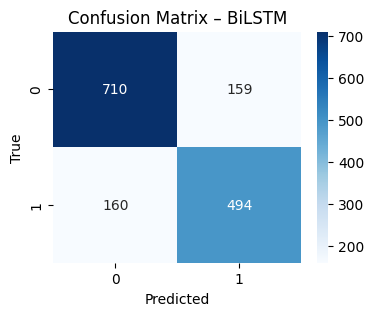

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – BiLSTM")
plt.show()

## 7. Tiny Hyperparameter Tuning

Trying to get a little more performance without using up to much ressources, I will try out 2 different configuartions and see wich one of them perfoms better (different number of embedding dimansions).

- Config 1: embedding_dim=64, lstm_units=64  
- Config 2: embedding_dim=128, lstm_units=64  


In [ ]:
konfigurationen = [
    {"name": "config_1", "embedding_dim": 64,  "lstm_units": 64,  "dropout": 0.5},
    {"name": "config_2", "embedding_dim": 128, "lstm_units": 64,  "dropout": 0.5},
]

tuning_ergebnisse = []

for konfig in konfigurationen:
    print(f"\n=== Training {konfig['name']} ===")
    m = baue_bilstm_modell(
        embedding_dim=konfig["embedding_dim"],
        lstm_units=konfig["lstm_units"],
        dropout_rate=konfig["dropout"]
    )

    hist = m.fit(
        X_train_gepadded,
        y_train,
        validation_data=(X_val_gepadded, y_val),
        epochs=4,
        batch_size=64,
        callbacks=[EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)],
        verbose=0
    )

    y_val_pred_prob = m.predict(X_val_gepadded)
    y_val_pred = (y_val_pred_prob > 0.5).astype(int)
    acc = accuracy_score(y_val, y_val_pred)
    print(f"{konfig['name']} val accuracy: {acc:.4f}")

    tuning_ergebnisse.append({
        "name": konfig["name"],
        "embedding_dim": konfig["embedding_dim"],
        "lstm_units": konfig["lstm_units"],
        "dropout": konfig["dropout"],
        "val_accuracy": acc
    })

tuning_ergebnisse_df = pd.DataFrame(tuning_ergebnisse)
tuning_ergebnisse_df


=== Training config_1 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
config_1 val accuracy: 0.8063

=== Training config_2 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
config_2 val accuracy: 0.8011


,name,embedding_dim,lstm_units,dropout,val_accuracy
0,config_1,64,64,0.5,0.806303
1,config_2,128,64,0.5,0.801051


## 8. Train Final Model on Full Training Data & Create Submission

The first config performed better so I will use it to make the final Kaggle submission // generate the csv for the competition


In [ ]:
BESTE_EINBETTUNG_DIM = 64
BESTE_LSTM_EINHEITEN = 64
BESTES_DROPOUT = 0.5

volle_texte = train_daten["clean_text"].values
volle_ziele = train_daten["target"].values

tokenisierer_voll = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenisierer_voll.fit_on_texts(volle_texte)

volle_sequenzen = tokenisierer_voll.texts_to_sequences(volle_texte)
voll_X_gepadded = pad_sequences(volle_sequenzen, maxlen=MAX_SEQUENCE_LENGTH,
                           padding="post", truncating="post")

end_modell = baue_bilstm_modell(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=BESTE_EINBETTUNG_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    lstm_units=BESTE_LSTM_EINHEITEN,
    dropout_rate=BESTES_DROPOUT
)

end_modell.summary()

verlauf_voll = end_modell.fit(
    voll_X_gepadded,
    volle_ziele,
    validation_split=0.1,
    epochs=6,
    batch_size=64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6006 - loss: 0.6618 - val_accuracy: 0.7743 - val_loss: 0.4641
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8383 - loss: 0.3909 - val_accuracy: 0.7822 - val_loss: 0.4736
Epoch 3/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9145 - loss: 0.2341 - val_accuracy: 0.7507 - val_loss: 0.5393


In [ ]:
# Predict on test set and create submission file

test_sequenzen = tokenisierer_voll.texts_to_sequences(test_daten["clean_text"].values)
test_X_gepadded = pad_sequences(test_sequenzen, maxlen=MAX_SEQUENCE_LENGTH,
                           padding="post", truncating="post")

test_vorhersage_wahrsch = end_modell.predict(test_X_gepadded)
test_vorhersage = (test_vorhersage_wahrsch > 0.5).astype(int).ravel()

submission = pd.DataFrame({
    "id": test_daten["id"],
    "target": test_vorhersage
})

einreichung_dateiname = "submission_kaggle.csv"
submission.to_csv(einreichung_dateiname, index=False)
print(f"Saved submission to {einreichung_dateiname}")

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Saved submission to submission_bilstm_from_kaggle.csv


## 9. Conclusion

The model perfomed overall okay, I had problems in the start getting the embedding to work, but it resolved itself (I think this was something wrong with my colab notebook)
